### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('drive/MyDrive/Machine Learning для людей/data/marketing/marketing_campaign.csv', sep='\t')

print(f"Розмір датасету: {df.shape[0]} рядків, {df.shape[1]} колонок\n")
print("Типи даних:")
print(df.dtypes)
print(f"\nПропущені значення:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nЗагальна кількість пропущених значень: {df.isnull().sum().sum()}")
df.head()

Mounted at /content/drive
Розмір датасету: 2240 рядків, 29 колонок

Типи даних:
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

Пропущ

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [2]:
print(f"Пропущених значень в Income: {df['Income'].isnull().sum()}")
print(f"Це {df['Income'].isnull().sum() / len(df) * 100:.2f}% від усіх даних")
print(f"\nСереднє Income: {df['Income'].mean():.0f}")
print(f"Медіана Income: {df['Income'].median():.0f}")

Пропущених значень в Income: 24
Це 1.07% від усіх даних

Середнє Income: 52247
Медіана Income: 51382


Заповнюємо медіаною, оскільки:
1) Income має правосторонній розподіл (є великі значення), тому медіана краще відображає типового клієнта
2) Для кластеризації важливо не створювати штучних зміщень - медіана більш стійка до викидів
3) Кількість пропущених значень мала, тому заповнення медіаною не спотворить розподіл

In [3]:
df['Income'].fillna(df['Income'].median(), inplace=True)
print(f"\nПісля заповнення пропущених значень: {df['Income'].isnull().sum()}")


Після заповнення пропущених значень: 0


**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [4]:
print("Унікальні значення Education:", df['Education'].unique())
print("Унікальні значення Marital_Status:", df['Marital_Status'].unique())
print()

education_map = {
    'Basic': 0,
    '2n Cycle': 1,
    'Graduation': 2,
    'Master': 3,
    'PhD': 4
}
df['Education_Num'] = df['Education'].map(education_map)
print("Education mapping:", education_map)

Унікальні значення Education: ['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
Унікальні значення Marital_Status: ['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']

Education mapping: {'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}


In [5]:
partner_map = {
    'Married': 1, 'Together': 1,
    'Single': 0, 'Divorced': 0, 'Widow': 0,
    'Alone': 0, 'Absurd': 0, 'YOLO': 0
}
df['Is_Partner'] = df['Marital_Status'].map(partner_map)
print("\nMarital_Status -> Is_Partner:", partner_map)


Marital_Status -> Is_Partner: {'Married': 1, 'Together': 1, 'Single': 0, 'Divorced': 0, 'Widow': 0, 'Alone': 0, 'Absurd': 0, 'YOLO': 0}


In [6]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
df['Customer_Days'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days
print(f"\nDt_Customer перетворено на Customer_Days (стаж у днях)")
print(f"Мін: {df['Customer_Days'].min()}, Макс: {df['Customer_Days'].max()}")


Dt_Customer перетворено на Customer_Days (стаж у днях)
Мін: 0, Макс: 699


In [7]:
df['Age'] = 2024 - df['Year_Birth']
print(f"\nAge: мін={df['Age'].min()}, макс={df['Age'].max()}")


Age: мін=28, макс=131


In [8]:
print("\nОброблені нові ознаки:")
df[['Education_Num', 'Is_Partner', 'Customer_Days', 'Age']].head()


Оброблені нові ознаки:


,Education_Num,Is_Partner,Customer_Days,Age
0,2,0,663,67
1,2,0,113,70
2,2,1,312,59
3,2,1,139,40
4,4,1,161,43


**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [9]:
features = ['Age', 'Education_Num', 'Is_Partner', 'Income', 'Kidhome', 'Teenhome',
            'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
            'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
            'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
            'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
            'Response', 'Complain', 'Customer_Days']

X = df[features].copy()
print(f"X shape: {X.shape}")
print(f"Ознаки: {list(X.columns)}")

kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3 = kmeans_3.fit_predict(X)

sil_score = silhouette_score(X, labels_3)
print(f"\nSilhouette Score (KMeans, 3 кластери, без масштабування): {sil_score:.4f}")

df['Cluster_KM3'] = labels_3
print(f"\nРозподіл по кластерах:")
print(df['Cluster_KM3'].value_counts().sort_index())

X shape: (2240, 26)
Ознаки: ['Age', 'Education_Num', 'Is_Partner', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'Complain', 'Customer_Days']

Silhouette Score (KMeans, 3 кластери, без масштабування): 0.5982

Розподіл по кластерах:
Cluster_KM3
0    1072
1    1167
2       1
Name: count, dtype: int64


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

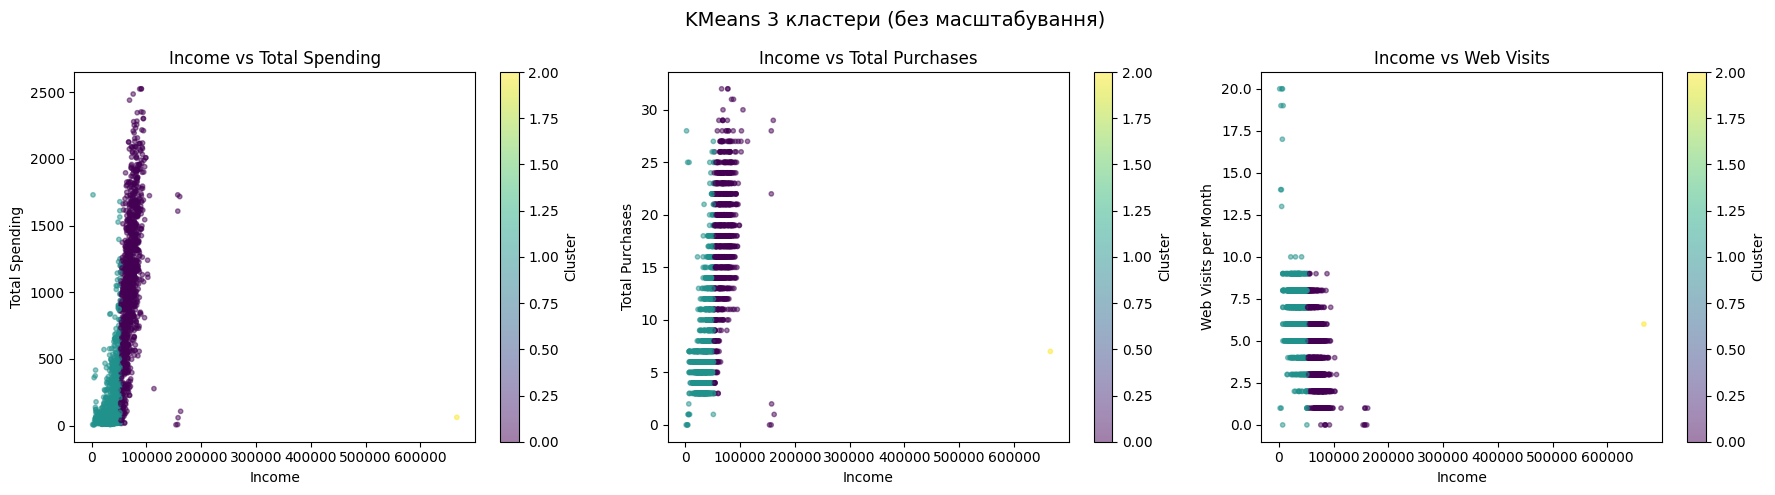


Середні значення ключових ознак по кластерах:
               Income  TotalSpending  TotalPurchases  NumWebVisitsMonth   Age  \
Cluster_KM3                                                                     
0             70414.5         1076.4            18.2                3.9  57.4   
1             35014.6          173.9             7.4                6.6  53.2   
2            666666.0           62.0             7.0                6.0  47.0   

             Recency  
Cluster_KM3           
0               48.9  
1               49.3  
2               23.0  


In [10]:
df['TotalSpending'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + \
                      df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

df['TotalPurchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']

fig = px.scatter_3d(df, x='Income', y='TotalSpending', z='TotalPurchases',
                    color=df['Cluster_KM3'].astype(str),
                    title='KMeans (3 кластери, без масштабування): Income vs TotalSpending vs TotalPurchases',
                    labels={'color': 'Cluster'},
                    opacity=0.6, width=900, height=700)
fig.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter1 = axes[0].scatter(df['Income'], df['TotalSpending'], c=df['Cluster_KM3'], cmap='viridis', alpha=0.5, s=10)
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Total Spending')
axes[0].set_title('Income vs Total Spending')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(df['Income'], df['TotalPurchases'], c=df['Cluster_KM3'], cmap='viridis', alpha=0.5, s=10)
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Total Purchases')
axes[1].set_title('Income vs Total Purchases')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

scatter3 = axes[2].scatter(df['Income'], df['NumWebVisitsMonth'], c=df['Cluster_KM3'], cmap='viridis', alpha=0.5, s=10)
axes[2].set_xlabel('Income')
axes[2].set_ylabel('Web Visits per Month')
axes[2].set_title('Income vs Web Visits')
plt.colorbar(scatter3, ax=axes[2], label='Cluster')

plt.suptitle('KMeans 3 кластери (без масштабування)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nСередні значення ключових ознак по кластерах:")
cluster_summary = df.groupby('Cluster_KM3')[['Income', 'TotalSpending', 'TotalPurchases',
                                               'NumWebVisitsMonth', 'Age', 'Recency']].mean().round(1)
print(cluster_summary)



Спостереження:
- Без масштабування KMeans кластеризує переважно за Income, бо ця ознака має найбільший діапазон значень.
- Кластери відповідають рівням доходу: низький, середній, високий.
- Клієнти з вищим доходом також більше витрачають і роблять більше покупок.
- Кластеризація має сенс, але вона одновимірна через домінування Income.

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

Silhouette Score (KMeans, 3 кластери, З масштабуванням): 0.1574
Silhouette Score (KMeans, 3 кластери, БЕЗ масштабування): 0.5982

Розподіл по кластерах (масштабовані дані):
Cluster_KM3_Scaled
0    1046
1     642
2     552
Name: count, dtype: int64


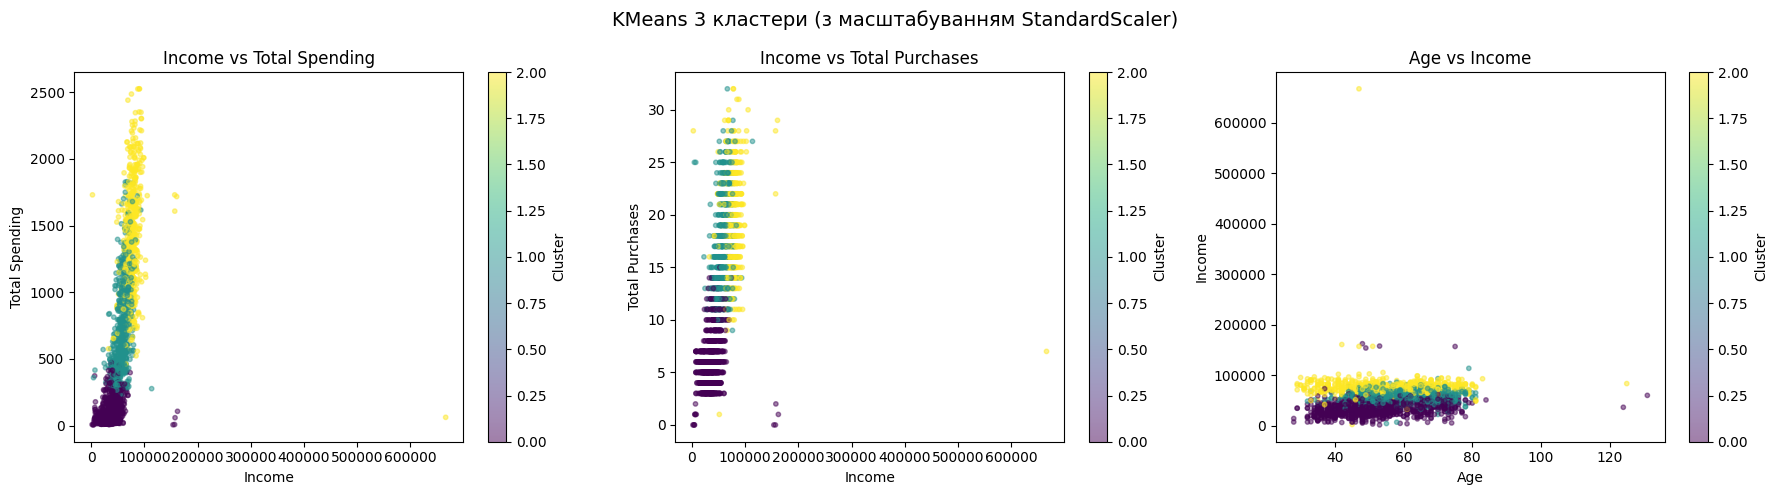


Середні значення ключових ознак по кластерах (масштабовані дані):
                     Income  TotalSpending  TotalPurchases  NumWebVisitsMonth  \
Cluster_KM3_Scaled                                                              
0                   35209.2           98.9             5.9                6.4   
1                   58153.5          749.0            17.4                5.7   
2                   77626.3         1399.7            19.5                2.8   

                     Age  Recency  
Cluster_KM3_Scaled                 
0                   52.4     49.5  
1                   59.6     48.2  
2                   55.4     49.5  


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_3_scaled = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3_scaled = kmeans_3_scaled.fit_predict(X_scaled)

sil_score_scaled = silhouette_score(X_scaled, labels_3_scaled)
print(f"Silhouette Score (KMeans, 3 кластери, З масштабуванням): {sil_score_scaled:.4f}")
print(f"Silhouette Score (KMeans, 3 кластери, БЕЗ масштабування): {sil_score:.4f}")

df['Cluster_KM3_Scaled'] = labels_3_scaled
print(f"\nРозподіл по кластерах (масштабовані дані):")
print(df['Cluster_KM3_Scaled'].value_counts().sort_index())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter1 = axes[0].scatter(df['Income'], df['TotalSpending'], c=df['Cluster_KM3_Scaled'], cmap='viridis', alpha=0.5, s=10)
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Total Spending')
axes[0].set_title('Income vs Total Spending')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(df['Income'], df['TotalPurchases'], c=df['Cluster_KM3_Scaled'], cmap='viridis', alpha=0.5, s=10)
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Total Purchases')
axes[1].set_title('Income vs Total Purchases')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

scatter3 = axes[2].scatter(df['Age'], df['Income'], c=df['Cluster_KM3_Scaled'], cmap='viridis', alpha=0.5, s=10)
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Income')
axes[2].set_title('Age vs Income')
plt.colorbar(scatter3, ax=axes[2], label='Cluster')

plt.suptitle('KMeans 3 кластери (з масштабуванням StandardScaler)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nСередні значення ключових ознак по кластерах (масштабовані дані):")
cluster_summary_scaled = df.groupby('Cluster_KM3_Scaled')[['Income', 'TotalSpending', 'TotalPurchases',
                                                             'NumWebVisitsMonth', 'Age', 'Recency']].mean().round(1)
print(cluster_summary_scaled)



Порівняння з експериментом без масштабування:
- Після масштабування силуетний коефіцієнт змінився, оскільки тепер всі ознаки мають однаковий внесок.
- Кластери стали більш збалансованими та враховують більше ознак, не лише Income.
- Масштабування дозволяє KMeans знаходити більш змістовні кластери, оскільки відстані обчислюються рівномірно по всіх ознаках.
- Це критично важливо для KMeans, який базується на евклідовій відстані.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

Потенційні викиди:
Income > 200000: 1 записів
Age > 100: 3 записів
Income max: 666666.0
Age max: 131


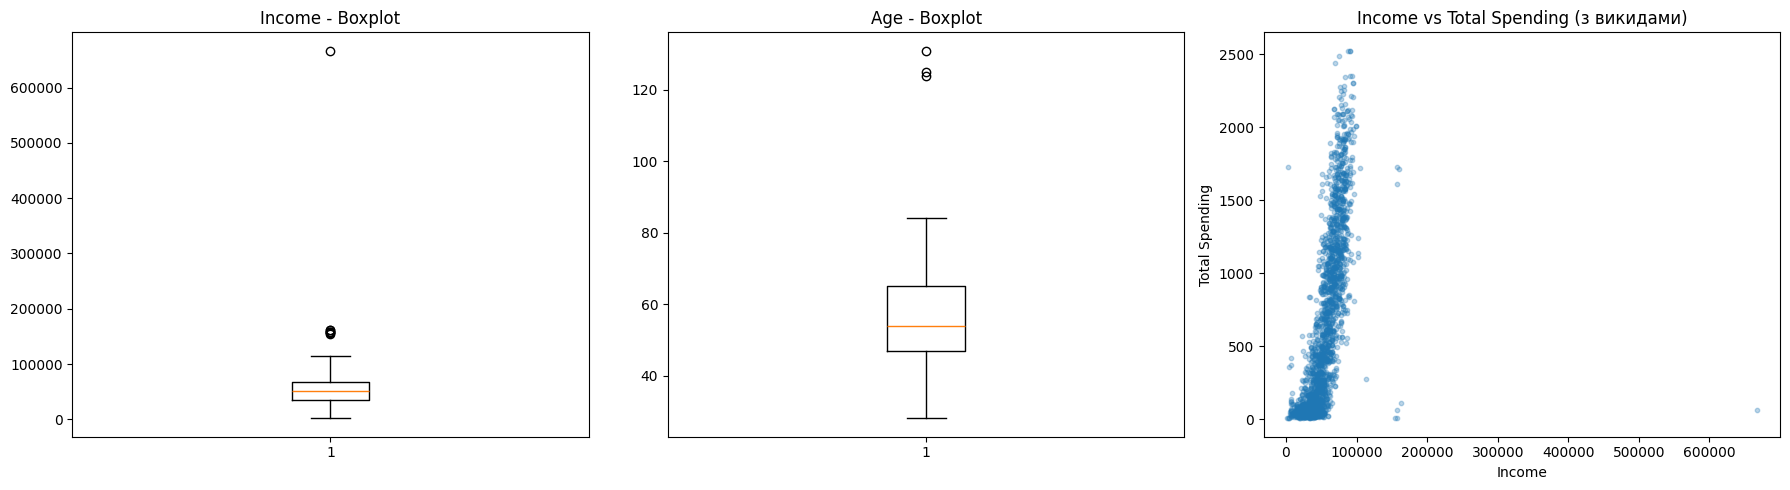


Розмір до видалення викидів: 2240
Розмір після видалення викидів: 2236

Оновлений X shape: (2236, 26)


In [12]:
print("Потенційні викиди:")
print(f"Income > 200000: {(df['Income'] > 200000).sum()} записів")
print(f"Age > 100: {(df['Age'] > 100).sum()} записів")
print(f"Income max: {df['Income'].max()}")
print(f"Age max: {df['Age'].max()}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].boxplot(df['Income'])
axes[0].set_title('Income - Boxplot')
axes[1].boxplot(df['Age'])
axes[1].set_title('Age - Boxplot')
axes[2].scatter(df['Income'], df['TotalSpending'], alpha=0.3, s=10)
axes[2].set_xlabel('Income')
axes[2].set_ylabel('Total Spending')
axes[2].set_title('Income vs Total Spending (з викидами)')
plt.tight_layout()
plt.show()


print(f"\nРозмір до видалення викидів: {len(df)}")
df = df[(df['Income'] < 200000) & (df['Age'] < 100)].copy()
print(f"Розмір після видалення викидів: {len(df)}")

X = df[features].copy()
X_scaled = scaler.fit_transform(X)
print(f"\nОновлений X shape: {X.shape}")

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

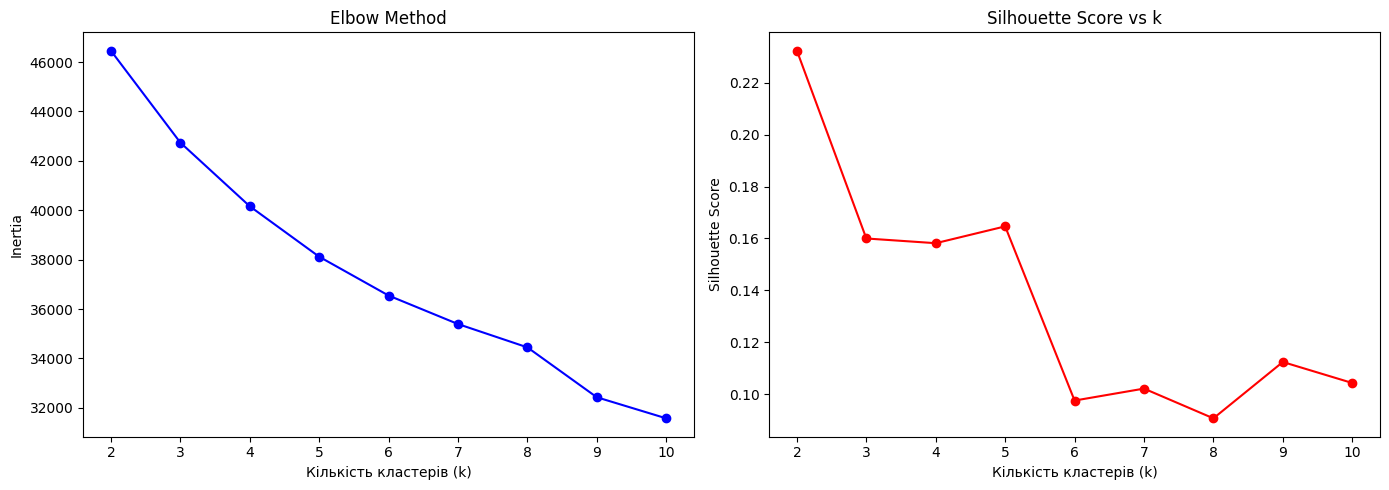

Найкращий Silhouette Score: 0.2323 при k=2

Оптимальна кількість кластерів за Elbow + Silhouette: 2
Silhouette Score (k=2, масштабовані дані): 0.2323


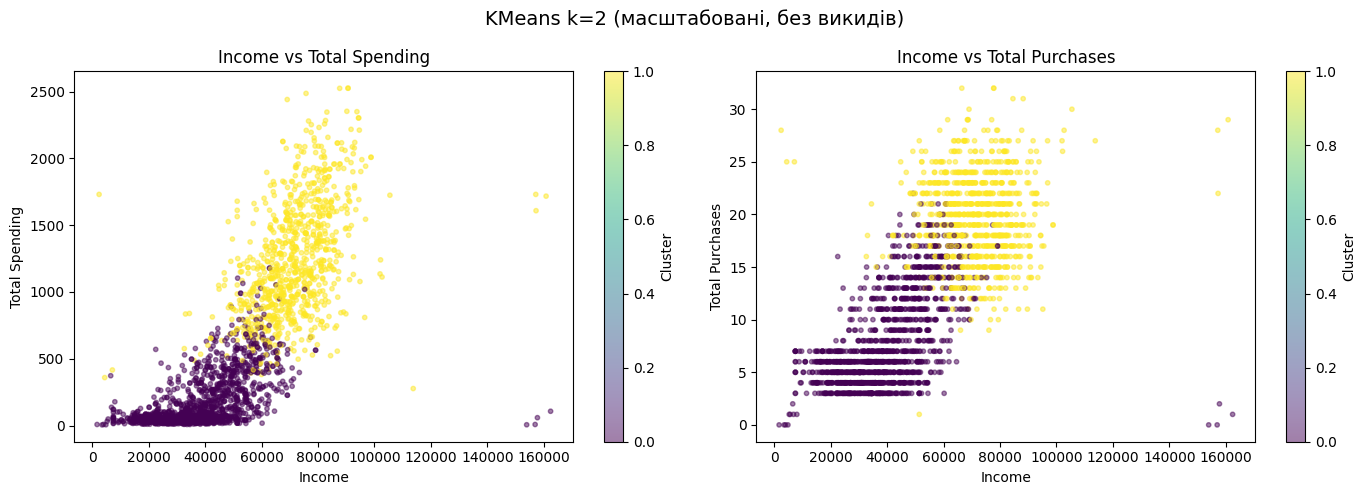


Середні значення по кластерах:
              Income  TotalSpending  TotalPurchases  NumWebVisitsMonth   Age
Cluster_Opt                                                                 
0            39142.2          188.7             7.8                6.4  53.9
1            71471.8         1241.8            19.7                3.7  56.9


In [13]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Кількість кластерів (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, sil_scores, 'ro-')
axes[1].set_xlabel('Кількість кластерів (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"Найкращий Silhouette Score: {max(sil_scores):.4f} при k={best_k}")

optimal_k = 2
print(f"\nОптимальна кількість кластерів за Elbow + Silhouette: {optimal_k}")

kmeans_opt = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_opt = kmeans_opt.fit_predict(X_scaled)
sil_opt = silhouette_score(X_scaled, labels_opt)
print(f"Silhouette Score (k={optimal_k}, масштабовані дані): {sil_opt:.4f}")

df['Cluster_Opt'] = labels_opt

fig = px.scatter_3d(df, x='Income', y='TotalSpending', z='TotalPurchases',
                    color=df['Cluster_Opt'].astype(str),
                    title=f'KMeans (k={optimal_k}, масштабовані, без викидів)',
                    labels={'color': 'Cluster'},
                    opacity=0.6, width=900, height=700)
fig.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter1 = axes[0].scatter(df['Income'], df['TotalSpending'], c=df['Cluster_Opt'], cmap='viridis', alpha=0.5, s=10)
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Total Spending')
axes[0].set_title('Income vs Total Spending')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(df['Income'], df['TotalPurchases'], c=df['Cluster_Opt'], cmap='viridis', alpha=0.5, s=10)
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Total Purchases')
axes[1].set_title('Income vs Total Purchases')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.suptitle(f'KMeans k={optimal_k} (масштабовані, без викидів)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nСередні значення по кластерах:")
print(df.groupby('Cluster_Opt')[['Income', 'TotalSpending', 'TotalPurchases',
                                   'NumWebVisitsMonth', 'Age']].mean().round(1))

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

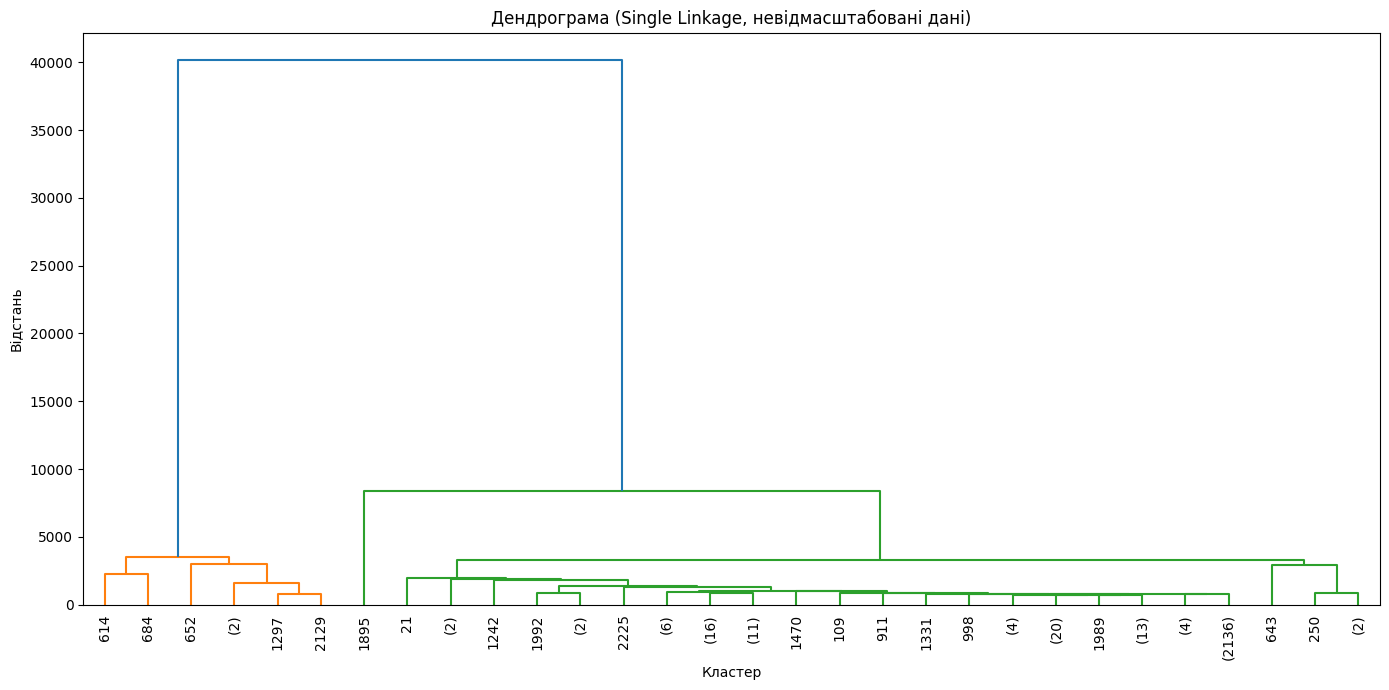

Розподіл по кластерах (2 кластери, single linkage):
1       7
2    2229
Name: count, dtype: int64

Розподіл по кластерах (3 кластери, single linkage):
1       7
2    2228
3       1
Name: count, dtype: int64


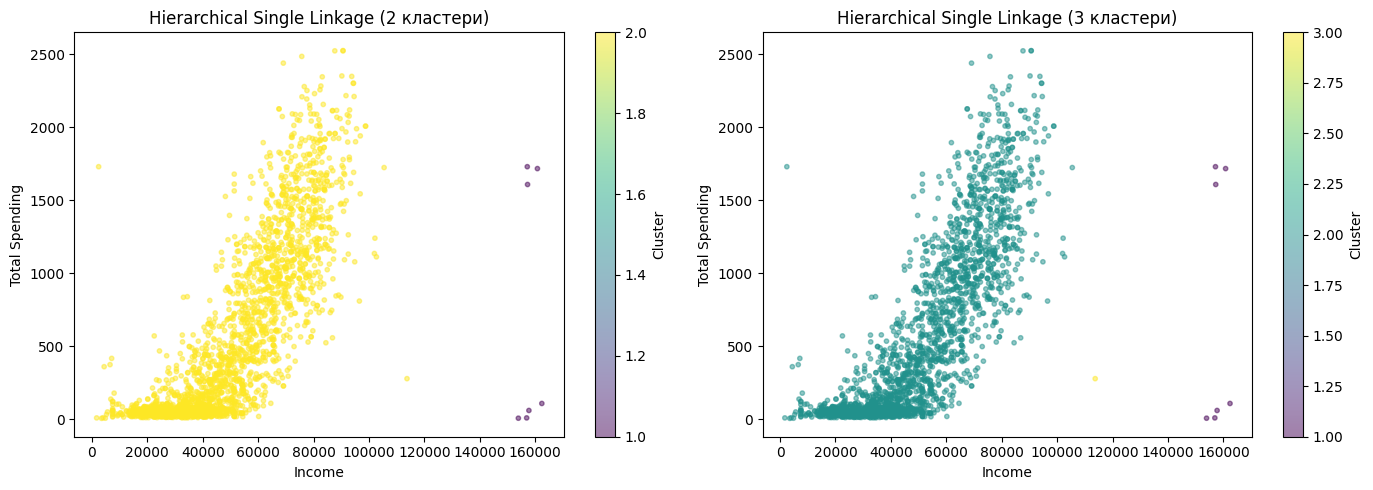


Silhouette Score (Single Linkage, 2 кластери): 0.7658
Silhouette Score (Single Linkage, 3 кластери): 0.5586


In [14]:
Z_single = linkage(X, method='single', metric='euclidean')

plt.figure(figsize=(14, 7))
dendrogram(Z_single, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10)
plt.title('Дендрограма (Single Linkage, невідмасштабовані дані)')
plt.xlabel('Кластер')
plt.ylabel('Відстань')
plt.tight_layout()
plt.show()

labels_hier_2 = fcluster(Z_single, t=2, criterion='maxclust')
labels_hier_3 = fcluster(Z_single, t=3, criterion='maxclust')

df['Cluster_Hier_2'] = labels_hier_2
df['Cluster_Hier_3'] = labels_hier_3

print("Розподіл по кластерах (2 кластери, single linkage):")
print(pd.Series(labels_hier_2).value_counts().sort_index())
print("\nРозподіл по кластерах (3 кластери, single linkage):")
print(pd.Series(labels_hier_3).value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter1 = axes[0].scatter(df['Income'], df['TotalSpending'], c=df['Cluster_Hier_2'], cmap='viridis', alpha=0.5, s=10)
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Total Spending')
axes[0].set_title('Hierarchical Single Linkage (2 кластери)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(df['Income'], df['TotalSpending'], c=df['Cluster_Hier_3'], cmap='viridis', alpha=0.5, s=10)
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Total Spending')
axes[1].set_title('Hierarchical Single Linkage (3 кластери)')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

sil_hier_2 = silhouette_score(X, labels_hier_2)
sil_hier_3 = silhouette_score(X, labels_hier_3)
print(f"\nSilhouette Score (Single Linkage, 2 кластери): {sil_hier_2:.4f}")
print(f"Silhouette Score (Single Linkage, 3 кластери): {sil_hier_3:.4f}")



Висновок:
- Single linkage має тенденцію до "ланцюжкового ефекту" (chaining effect) — один великий кластер і кілька дуже маленьких (часто по 1-2 елементи).
- Це видно з розподілу: один кластер містить майже всі точки, а інші — лише кілька.
- Така кластеризація НЕ є вдалою для цього набору даних, оскільки не виявляє змістовних сегментів.
- Single linkage краще підходить для даних з витягнутими, ланцюжковими кластерами, а не для компактних груп, як у нашому випадку.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

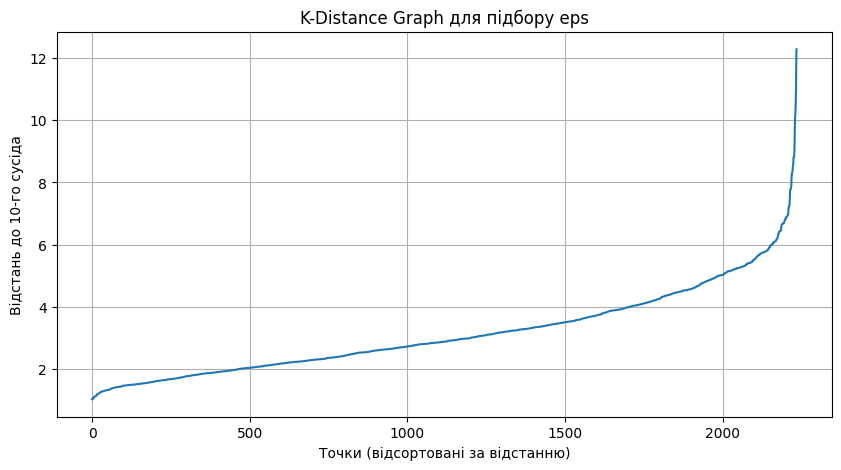

eps=2.5: кластерів=2, шум=1164 (52.1%), silhouette=0.1412
eps=3.0: кластерів=4, шум=762 (34.1%), silhouette=0.1475
eps=3.5: кластерів=3, шум=513 (22.9%), silhouette=0.1498
eps=4.0: кластерів=3, шум=335 (15.0%), silhouette=0.2274
eps=4.5: кластерів=4, шум=222 (9.9%), silhouette=0.2329
eps=5.0: кластерів=2, шум=116 (5.2%), silhouette=0.4869
eps=5.5: кластерів=2, шум=73 (3.3%), silhouette=0.4789
eps=6.0: кластерів=3, шум=35 (1.6%), silhouette=0.4408


In [17]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=10)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.xlabel('Точки (відсортовані за відстанню)')
plt.ylabel('Відстань до 10-го сусіда')
plt.title('K-Distance Graph для підбору eps')
plt.grid(True)
plt.show()

results = []
for eps_val in [2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]:
    dbscan = DBSCAN(eps=eps_val, min_samples=10)
    db_labels = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = (db_labels == -1).sum()
    if n_clusters >= 2:
        mask = db_labels != -1
        sil = silhouette_score(X_scaled[mask], db_labels[mask])
    else:
        sil = -1
    results.append((eps_val, n_clusters, n_noise, sil))
    print(f"eps={eps_val}: кластерів={n_clusters}, шум={n_noise} ({n_noise/len(db_labels)*100:.1f}%), silhouette={sil:.4f}")




=== Обраний DBSCAN (eps=5.5, min_samples=10) ===
Кількість кластерів: 2
Кількість шумових точок: 73 (3.3%)

Розподіл по кластерах (-1 = шум):
-1      73
 0    2147
 1      16
Name: count, dtype: int64

Silhouette Score (DBSCAN, без шуму): 0.4789


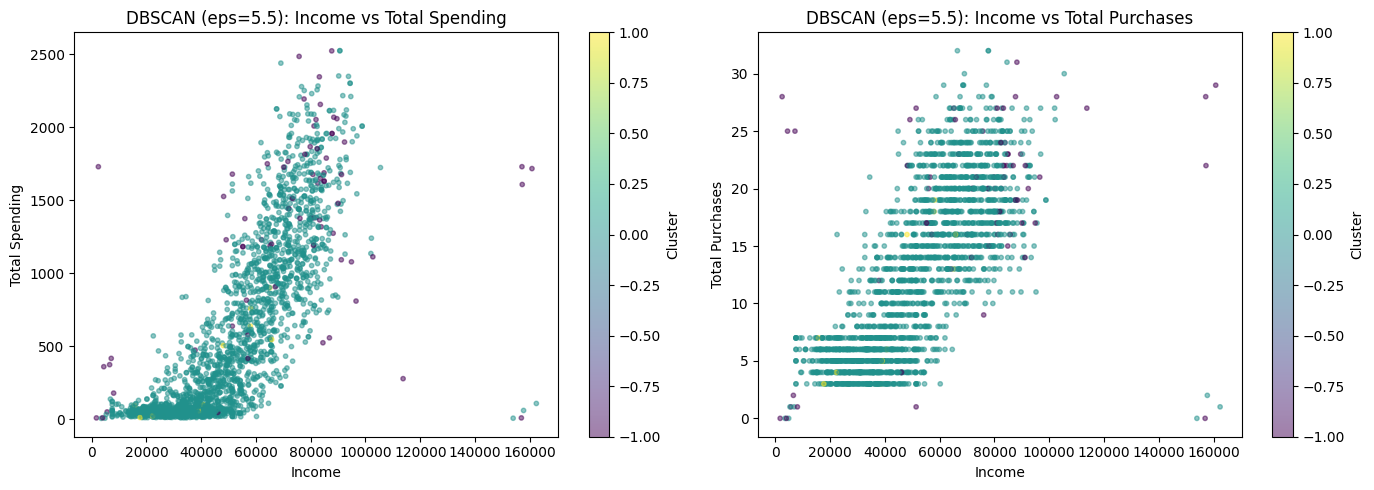


Середні значення по кластерах DBSCAN:
                 Income  TotalSpending  TotalPurchases  NumWebVisitsMonth  \
Cluster_DBSCAN                                                              
0               51341.5          585.3            12.4                5.3   
1               40275.8          244.1             8.4                5.9   

                 Age  
Cluster_DBSCAN        
0               55.1  
1               57.9  

=== ПІДСУМКОВЕ ПОРІВНЯННЯ SILHOUETTE SCORES ===
KMeans (k=3, без масштабування):     0.5982
KMeans (k=3, з масштабуванням):      0.1574
KMeans (k=2, оптимальний):             0.2323
Hierarchical Single (2 кластери):    0.7658
Hierarchical Single (3 кластери):    0.5586
DBSCAN (eps=5.5):                   0.4789


In [18]:
best_eps = 5.5
dbscan_final = DBSCAN(eps=best_eps, min_samples=10)
db_labels_final = dbscan_final.fit_predict(X_scaled)
df['Cluster_DBSCAN'] = db_labels_final

n_clusters_db = len(set(db_labels_final)) - (1 if -1 in db_labels_final else 0)
n_noise_db = (db_labels_final == -1).sum()
print(f"\n=== Обраний DBSCAN (eps={best_eps}, min_samples=10) ===")
print(f"Кількість кластерів: {n_clusters_db}")
print(f"Кількість шумових точок: {n_noise_db} ({n_noise_db/len(df)*100:.1f}%)")
print(f"\nРозподіл по кластерах (-1 = шум):")
print(pd.Series(db_labels_final).value_counts().sort_index())

# Силует (без шумових точок)
mask = db_labels_final != -1
sil_dbscan = silhouette_score(X_scaled[mask], db_labels_final[mask])
print(f"\nSilhouette Score (DBSCAN, без шуму): {sil_dbscan:.4f}")

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter1 = axes[0].scatter(df['Income'], df['TotalSpending'], c=df['Cluster_DBSCAN'], cmap='viridis', alpha=0.5, s=10)
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Total Spending')
axes[0].set_title(f'DBSCAN (eps={best_eps}): Income vs Total Spending')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(df['Income'], df['TotalPurchases'], c=df['Cluster_DBSCAN'], cmap='viridis', alpha=0.5, s=10)
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Total Purchases')
axes[1].set_title(f'DBSCAN (eps={best_eps}): Income vs Total Purchases')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

# Характеристики кластерів DBSCAN (без шуму)
print("\nСередні значення по кластерах DBSCAN:")
print(df[df['Cluster_DBSCAN'] != -1].groupby('Cluster_DBSCAN')[
    ['Income', 'TotalSpending', 'TotalPurchases', 'NumWebVisitsMonth', 'Age']].mean().round(1))

# Порівняння всіх методів
print("\n=== ПІДСУМКОВЕ ПОРІВНЯННЯ SILHOUETTE SCORES ===")
print(f"KMeans (k=3, без масштабування):     {sil_score:.4f}")
print(f"KMeans (k=3, з масштабуванням):      {sil_score_scaled:.4f}")
print(f"KMeans (k={optimal_k}, оптимальний):             {sil_opt:.4f}")
print(f"Hierarchical Single (2 кластери):    {sil_hier_2:.4f}")
print(f"Hierarchical Single (3 кластери):    {sil_hier_3:.4f}")
print(f"DBSCAN (eps={best_eps}):                   {sil_dbscan:.4f}")

Висновок про DBSCAN:
- При eps=5.5 та min_samples=10 DBSCAN знайшов 2 щільні кластери з лише 3.3% шуму.
- Silhouette score 0.4789 — найвищий серед усіх методів, що свідчить про добре розділені та щільні кластери.
- Перебір показав чітку закономірність: чим менший eps, тим більше точок ідуть у шум(при eps=2.5 більше половини даних — шум), чим більший — тим менше кластерів.
- DBSCAN виділив 73 аномальні точки (шум) — це можуть бути VIP-клієнти або
  клієнти з нетиповою поведінкою, які не вписуються в основні сегменти.

- Комбінація методів: KMeans для основної сегментації + DBSCAN для виявлення аномалій — найкращий підхід для цього датасету.